# CMSE 201 Final Project 

#### CMSE 201 Final Project
### &#9989; Atticus Bartoli 
### &#9989; Section: 03
#### &#9989;  11/1/23

# ___How much does it cost to win in the NBA?___

## Background and Motivation

In the NBA there are 30 teams, and all of them have massive funding behind them. Each of these teams have the ultimate goal of winning a championship, and over the course of the last few decades basketball has changed a lot. The question I am looking to answer is how much does winning a championship cost in the NBA? And how has that price changed over time?

## Methodology

I have downloaded 4 datasets that I can use to answer this question. I will be using this data to find the average amounts teams were paying per season / year, and then use that information to look specifically at the teams that won championships. I have loaded them in below. 'The team Payroll and player salary data was scraped from Hoops Hype.' - datasets downloaded at link https://www.kaggle.com/datasets/loganlauton/nba-players-and-team-data/

Also using link: https://en.wikipedia.org/wiki/List_of_NBA_champions to find the champions of each year / season.


I quickly realized that I will be primarily using the NBAPayroll dataset. I am using this dataset because it has the entire team payrolls across each season. This is the data I will need to find the answer I am looking for. 

Using this dataset I made multiple pie charts to see which teams over various years have had the highest budgets, and visually how that correlates with winning. I chose to use the inflation adjusted payroll because it is best to have this consistency for comparison over the years. This goes for all plots and work moving forward. For each pie chart I did a small written statement about the results and the champion that year. 

After this I created some new data sets for specific teams that had rallies of championship wins. I did this to analyze historical patterns of championship wins, and I did written analysis on these results in the notes. The purpose of this was to become more knowledgeable before looking at more visual results.

The next step to my conclusions was creating a dataframe of winning teams from each year. I then used this dataframe to find the Inflation Adjusted Payroll for these teams in these particular seasons. After adding this to an additional column in my winningteams dataframe, I then plotted this. 

To take this a step further, I wanted to compare the winning teams' budget to the average budget. To do this I created another dataset of the average payroll for each year. I then created a series of plots, with the average budget and the winning budget graphed against time. The first graph across all years made me more intrigued about smaller trends across certain decades. So I decided to make two more with constraints on the time axis to get a better view of these periods. 

In the previous few steps, I was intrigued by the column 'Unnamed: 0' as I could clearly tell just by looking at the data and working with it that it was defined by the teams budget ranking out of the 30 teams. This gave me the idea to make a bar plot displaying a count of the budget ranks of the champions for the last 30 years. The results were exactly as I expected. I then calculated a mean and median ranking of champion teams. 

After doing some more redundant work, I finally ran a few basic equations to come to a few answers to my main question and print them all out. 

In [1]:
import pandas as pd

NBAsalaries = pd.read_csv('NBASalaries(1990-2023).csv')
NBAplayerstats = pd.read_csv('NBAPlayerStats(1950-2022).csv')
NBAplayerBSstats = pd.read_csv('NBAPlayerBoxScoreStats(1950-2022).csv')
NBAPayroll = pd.read_csv('NBAPayroll(1990-2023).csv')
print(NBAsalaries.head())
print(NBAplayerstats.head())
print(NBAplayerBSstats.head())
print(NBAPayroll.head())

   Unnamed: 0        playerName  seasonStartYear      salary  \
0           0     Patrick Ewing             1990  $4,250,000   
1           1  Hot Rod Williams             1990  $3,785,000   
2           2   Hakeem Olajuwon             1990  $3,175,000   
3           3   Charles Barkley             1990  $2,900,000   
4           4      Chris Mullin             1990  $2,850,000   

  inflationAdjSalary  
0         $9,694,547  
1         $8,633,850  
2         $7,242,397  
3         $6,615,103  
4         $6,501,049  
   Unnamed: 0.1  Unnamed: 0  Season           Player  Pos   Age   Tm     G  \
0             0           0    1950  Curly Armstrong  G-F  31.0  FTW  63.0   
1             1           1    1950     Cliff Barker   SG  29.0  INO  49.0   
2             2           2    1950    Leo Barnhorst   SF  25.0  CHS  67.0   
3             3           3    1950       Ed Bartels    F  24.0  TOT  15.0   
4             4           4    1950       Ed Bartels    F  24.0  DNN  13.0   

   GS  M

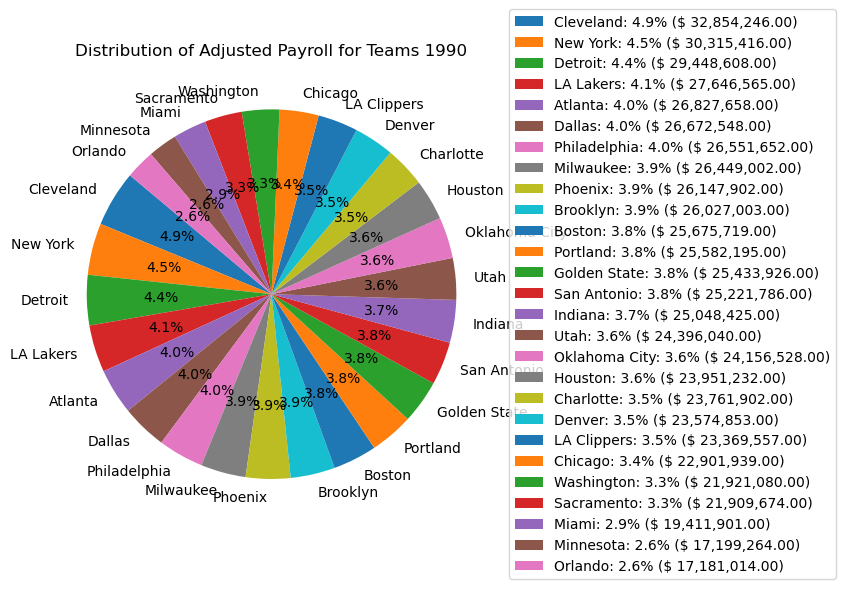

In [2]:
import matplotlib.pyplot as plt
NBAPayroll = NBAPayroll.dropna()
NBAPayroll

NBA1990_payroll = NBAPayroll.iloc[:27, [1, 4]]
NBA1990_payroll['inflationAdjPayroll'] = NBA1990_payroll['inflationAdjPayroll'].replace('[\$,]', '', regex=True).astype(float)

total_payroll = NBA1990_payroll['inflationAdjPayroll'].sum()
NBA1990_payroll['Percentage'] = (NBA1990_payroll['inflationAdjPayroll'] / total_payroll) * 100

plt.figure(figsize=(10, 6))
plt.pie(NBA1990_payroll['inflationAdjPayroll'], labels=NBA1990_payroll['team'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Adjusted Payroll for Teams 1990')
legend_labels = [f"{team}: {percentage:.1f}% ($ {inflationAdjPayroll:,.2f})" 
                 for team, percentage, inflationAdjPayroll in zip(NBA1990_payroll['team'], 
                                                         (NBA1990_payroll['inflationAdjPayroll'] / total_payroll) * 100, 
                                                         NBA1990_payroll['inflationAdjPayroll'])]

plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

## The champions this year were the Detroit Pistons, and they are the third highest payroll for this season coming in at 29.45 million in todays dollars. 

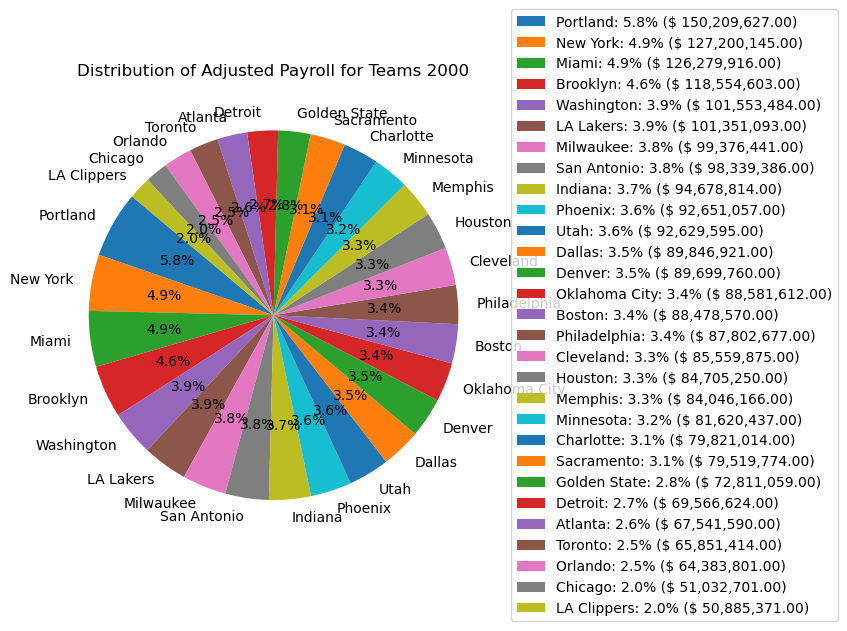

In [3]:
NBA2000_payroll = NBAPayroll.iloc[280:309, [1, 4]]
NBA2000_payroll['inflationAdjPayroll'] = NBA2000_payroll['inflationAdjPayroll'].replace('[\$,]', '', regex=True).astype(float)

total_payroll = NBA2000_payroll['inflationAdjPayroll'].sum()
NBA2000_payroll['Percentage'] = (NBA2000_payroll['inflationAdjPayroll'] / total_payroll) * 100

plt.figure(figsize=(10, 6))
plt.pie(NBA2000_payroll['inflationAdjPayroll'], labels=NBA2000_payroll['team'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Adjusted Payroll for Teams 2000')
legend_labels = [f"{team}: {percentage:.1f}% ($ {inflationAdjPayroll:,.2f})" 
                 for team, percentage, inflationAdjPayroll in zip(NBA2000_payroll['team'], 
                                                         (NBA2000_payroll['inflationAdjPayroll'] / total_payroll) * 100, 
                                                         NBA2000_payroll['inflationAdjPayroll'])]

plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

## The champions this year were the LA Lakers, and they are the sixth highest payroll for this season coming in at $101 million in todays dollars.
## Worth noting that the budgets for these teams has increased by over 400% in the last decade. 

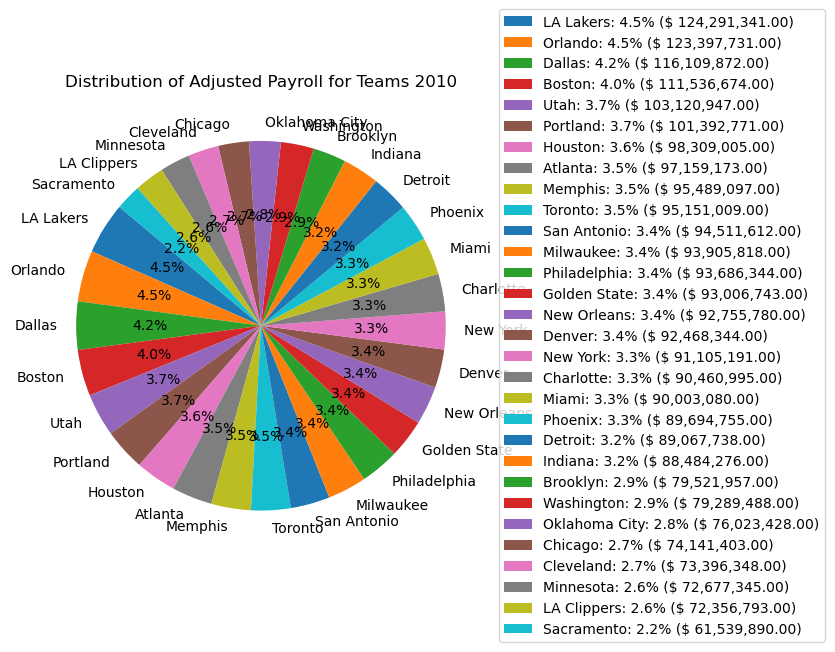

In [4]:
NBA2010_payroll = NBAPayroll.iloc[576:606, [1, 4]]
NBA2010_payroll['inflationAdjPayroll'] = NBA2010_payroll['inflationAdjPayroll'].replace('[\$,]', '', regex=True).astype(float)

total_payroll = NBA2010_payroll['inflationAdjPayroll'].sum()
NBA2010_payroll['Percentage'] = (NBA2010_payroll['inflationAdjPayroll'] / total_payroll) * 100

plt.figure(figsize=(10, 6))
plt.pie(NBA2010_payroll['inflationAdjPayroll'], labels=NBA2010_payroll['team'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Adjusted Payroll for Teams 2010')
legend_labels = [f"{team}: {percentage:.1f}% ($ {inflationAdjPayroll:,.2f})" 
                 for team, percentage, inflationAdjPayroll in zip(NBA2010_payroll['team'], 
                                                         (NBA2010_payroll['inflationAdjPayroll'] / total_payroll) * 100, 
                                                         NBA2010_payroll['inflationAdjPayroll'])]

plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

## The champions this year were the LA Lakers, and they are the highest payroll for this season coming in at $124 million in todays dollars.
## Worth noting that the budgets for these teams has not increased by very much in the last decade. 

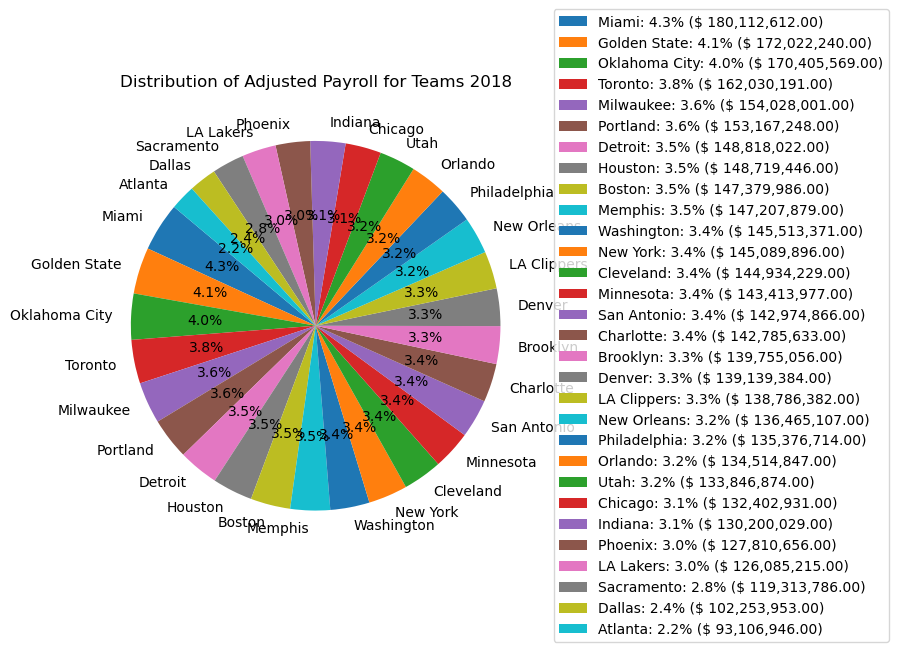

In [5]:
## Champions were 

NBA2018_payroll = NBAPayroll.iloc[816:846, [1, 4]]
NBA2018_payroll['inflationAdjPayroll'] = NBA2018_payroll['inflationAdjPayroll'].replace('[\$,]', '', regex=True).astype(float)

total_payroll = NBA2018_payroll['inflationAdjPayroll'].sum()
NBA2018_payroll['Percentage'] = (NBA2018_payroll['inflationAdjPayroll'] / total_payroll) * 100

plt.figure(figsize=(10, 6))
plt.pie(NBA2018_payroll['inflationAdjPayroll'], labels=NBA2018_payroll['team'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Adjusted Payroll for Teams 2018')
legend_labels = [f"{team}: {percentage:.1f}% ($ {inflationAdjPayroll:,.2f})" 
                 for team, percentage, inflationAdjPayroll in zip(NBA2018_payroll['team'], 
                                                         (NBA2018_payroll['inflationAdjPayroll'] / total_payroll) * 100, 
                                                         NBA2018_payroll['inflationAdjPayroll'])]

plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

## The champions this year were the Golden State Warriors, and they are the second highest payroll for this season coming in at $172 million in todays dollars.
## Worth noting that the budgets for these teams has continued to increase again in the 8 years. 

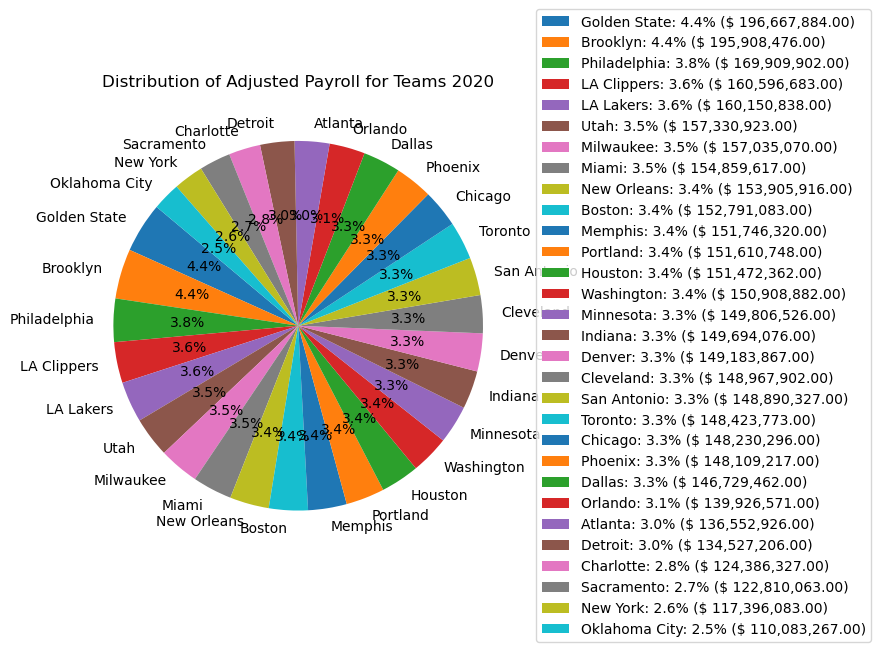

In [6]:
## Champions were 

NBA2020_payroll = NBAPayroll.iloc[876:906, [1, 4]]
NBA2020_payroll['inflationAdjPayroll'] = NBA2020_payroll['inflationAdjPayroll'].replace('[\$,]', '', regex=True).astype(float)

total_payroll = NBA2020_payroll['inflationAdjPayroll'].sum()
NBA2020_payroll['Percentage'] = (NBA2020_payroll['inflationAdjPayroll'] / total_payroll) * 100

plt.figure(figsize=(10, 6))
plt.pie(NBA2020_payroll['inflationAdjPayroll'], labels=NBA2020_payroll['team'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Adjusted Payroll for Teams 2020')
legend_labels = [f"{team}: {percentage:.1f}% ($ {inflationAdjPayroll:,.2f})" 
                 for team, percentage, inflationAdjPayroll in zip(NBA2020_payroll['team'], 
                                                         (NBA2020_payroll['inflationAdjPayroll'] / total_payroll) * 100, 
                                                         NBA2020_payroll['inflationAdjPayroll'])]

plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

## The champions this year were the LA Lakers, and they are the fourth highest payroll for this season coming in at $160 million in todays dollars.
## Worth noting that the top budgets for these teams has continued to increase 10% over the last 2 years. 

In [7]:
NBAPayroll
row_test1 = NBAPayroll.iloc[876]
print(row_test1)

row_test2 = NBAPayroll.iloc[905]
print(row_test2)


Unnamed: 0                        0
team                   Golden State
seasonStartYear                2020
payroll                $171,105,334
inflationAdjPayroll    $196,667,884
Name: 876, dtype: object
Unnamed: 0                        29
team                   Oklahoma City
seasonStartYear                 2020
payroll                  $95,774,839
inflationAdjPayroll     $110,083,267
Name: 905, dtype: object


In [8]:
## Consecutive winners.... accumulation of capital? 

## Winners for 1991, 1992, 1993, 1996, 1997, 1998 seasons are Chicago Bulls.
chicago_NBAPayroll = NBAPayroll[NBAPayroll['team'] == 'Chicago'].copy()

print(chicago_NBAPayroll)

## In order to win in 1991 and 1992, Chicago was the second and third highest budget team for these seasons. This increase in budget from 1990 to 1991 was over 60%. Chicago was a middle-range budget team after winning these championships, until 1996. 
## In 1996 and 1997 Chicago had the highest budget of all teams in the NBA for their second and third to last championships. This increase in budget from 1995 to 1996 is over 100%. After this, the budget was fractionized and the last championship was won in 1998. 

## Winners for 2000, 2001, 2002, 2009, 2010 seasons are LA Lakers. 
LA_NBAPayroll = NBAPayroll[NBAPayroll['team'] == 'LA Lakers'].copy()

print(LA_NBAPayroll)

## The LA Lakers have always been a higher-budget team, thus the large amount of championships they have won across history. After winning many times in the 80s their team was already high budget going into the 90s, where they did not have any wins. 
## The LA Lakers became interesting again in the early 2000s, winning championships in 2000, 2001, and 2002 with a lower comparitive budget. However, for the championships in 2009 and 2010, the LA Lakers were back to being the highest budget team in the NBA.


## Winners for 2015, 2017, 2018, 2022 seasons are Golden State Warriors.
GS_NBAPayroll = NBAPayroll[NBAPayroll['team'] == 'Golden State'].copy()

print(GS_NBAPayroll)

## The Golden State Warriors were historically a team with a mid-size budget, up until 2015. In order to go on the run of championships throughout 2015 to 2022, the Warriors increased their budget massively and rose to be the highest budget team in the NBA.
## From 2014 to 2015 for the championship win in 2015, Golden State Jumped from a 13th highest budget to the 3rd highest budget. For the next win in 2017, Golden State once again jumped from 13th highest budget in 2016 to the second highest budget in 2017 and 2018.
## After this run of wins, Golden State had the highest team budget for the 2020s going into their win for the 2022 Championship.

     Unnamed: 0     team  seasonStartYear       payroll inflationAdjPayroll
21           21  Chicago             1990   $10,040,000         $22,901,939
29            2  Chicago             1991   $16,829,000         $36,666,301
57            3  Chicago             1992   $18,536,000         $39,175,603
92           11  Chicago             1993   $18,531,000         $38,025,887
119          11  Chicago             1994   $22,053,129         $44,152,591
149          14  Chicago             1995   $23,512,000         $45,684,348
164           0  Chicago             1996   $58,270,000        $110,185,330
193           0  Chicago             1997   $61,330,670        $113,368,381
249          27  Chicago             1998   $28,640,500         $52,064,377
278          27  Chicago             1999   $27,032,368         $48,194,863
307          27  Chicago             2000   $29,691,907         $51,032,701
335          26  Chicago             2001   $42,592,857         $70,902,978
364         

    seasonStartYear          team  inflationAdjPayroll  Unnamed: 0
0              1990       Detroit           29448608.0           2
1              1991       Chicago           36666301.0           2
2              1992       Chicago           39175603.0           3
3              1993       Chicago           38025887.0          11
4              1994       Houston           35194129.0          23
5              1995       Houston           49803557.0           7
6              1996       Chicago          110185330.0           0
7              1997       Chicago          113368381.0           0
8              1998       Chicago           52064377.0          27
9              1999   San Antonio           75824590.0          16
10             2000     LA Lakers          101351093.0           5
11             2001     LA Lakers           90328263.0          11
12             2002     LA Lakers          104015499.0           5
13             2003   San Antonio           74947262.0        

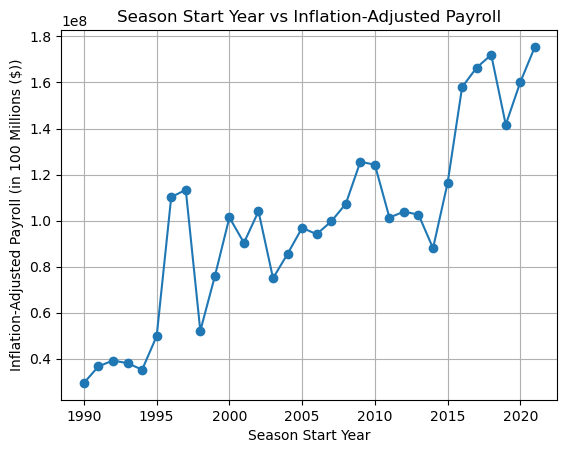

In [20]:
basketball = {
    'seasonStartYear': list(range(1990, 2022)),
    'team': [
        'Detroit', 'Chicago', 'Chicago', 'Chicago', 'Houston', 'Houston', 'Chicago', 'Chicago', 'Chicago',
        'San Antonio', 'LA Lakers', 'LA Lakers', 'LA Lakers', 'San Antonio', 'Detroit', 'San Antonio', 'Miami',
        'San Antonio', 'Boston', 'LA Lakers', 'LA Lakers', 'Dallas', 'Miami', 'Miami', 'San Antonio',
        'Golden State', 'Cleveland', 'Golden State', 'Golden State', 'Toronto', 'LA Lakers', 'Milwaukee'
    
    ]
}


## Using Wikipedia resource to create the dataframe above

winningteams_df = pd.DataFrame(basketball)

winningteams_df['inflationAdjPayroll'] = winningteams_df.apply(lambda row: NBAPayroll[(NBAPayroll['seasonStartYear'] == row['seasonStartYear']) & (NBAPayroll['team'] == row['team'])]['inflationAdjPayroll'].values[0], axis=1)
winningteams_df['Unnamed: 0'] = winningteams_df.apply(lambda row: NBAPayroll[(NBAPayroll['seasonStartYear'] == row['seasonStartYear']) & (NBAPayroll['team'] == row['team'])]['Unnamed: 0'].values[0], axis=1)

print(winningteams_df)

## Column 'Unnamed: 0' is essentially the rank of the team of their payroll. How high out of all 30 teams was their budget for the season.

winningteams_df['inflationAdjPayroll'] = winningteams_df['inflationAdjPayroll'].replace('[\$,]', '', regex=True).astype(float)


plt.plot(winningteams_df['seasonStartYear'], winningteams_df['inflationAdjPayroll'], 'o', linestyle='-')
plt.title('Season Start Year vs Inflation-Adjusted Payroll')
plt.xlabel('Season Start Year')
plt.ylabel('Inflation-Adjusted Payroll (in 100 Millions ($))')
plt.grid(True)
plt.show()

In [10]:
NBAPayroll['inflationAdjPayroll'] = NBAPayroll['inflationAdjPayroll'].replace('[\$,]', '', regex=True).astype(float)

average_payroll = NBAPayroll.groupby(NBAPayroll['seasonStartYear'])['inflationAdjPayroll'].mean().reset_index()
average_payroll.columns = ['seasonStartYear', 'AverageInflationAdjPayroll']

print(average_payroll)

    seasonStartYear  AverageInflationAdjPayroll
0              1990                2.480139e+07
1              1991                2.982331e+07
2              1992                3.357988e+07
3              1993                3.802569e+07
4              1994                4.439650e+07
5              1995                4.852649e+07
6              1996                5.240336e+07
7              1997                6.046039e+07
8              1998                6.706477e+07
9              1999                8.079017e+07
10             2000                8.912341e+07
11             2001                8.946747e+07
12             2002                9.483995e+07
13             2003                9.303304e+07
14             2004                9.234875e+07
15             2005                9.635667e+07
16             2006                9.440737e+07
17             2007                9.783962e+07
18             2008                9.743254e+07
19             2009                9.676

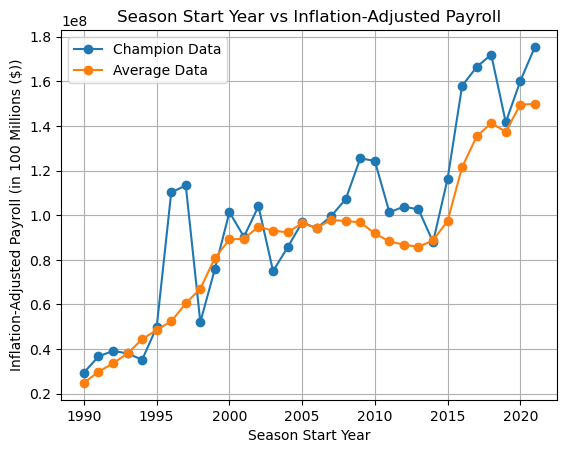

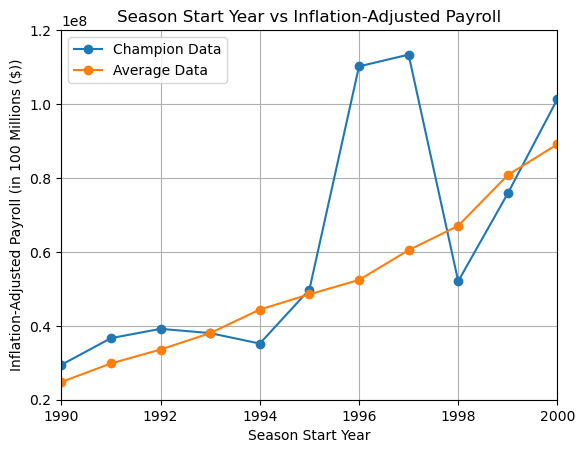

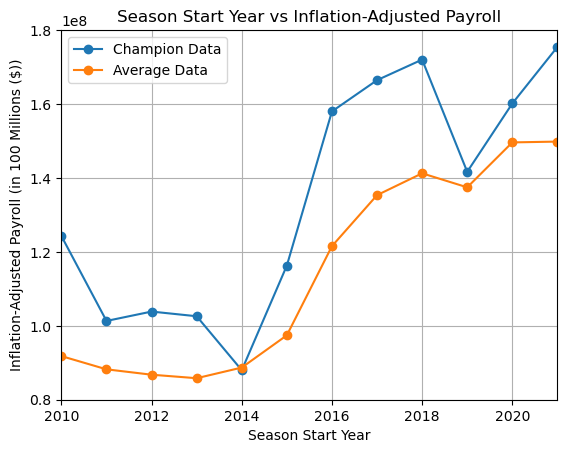

In [11]:
plt.plot(winningteams_df['seasonStartYear'], winningteams_df['inflationAdjPayroll'], 'o', linestyle='-', label='Champion Data')
plt.plot(average_payroll['seasonStartYear'], average_payroll['AverageInflationAdjPayroll'], 'o', linestyle='-', label = "Average Data")
plt.title('Season Start Year vs Inflation-Adjusted Payroll')
plt.xlabel('Season Start Year')
plt.ylabel('Inflation-Adjusted Payroll (in 100 Millions ($))')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(winningteams_df['seasonStartYear'], winningteams_df['inflationAdjPayroll'], 'o', linestyle='-', label='Champion Data')
plt.plot(average_payroll['seasonStartYear'], average_payroll['AverageInflationAdjPayroll'], 'o', linestyle='-', label = "Average Data")
plt.xlim(1990, 2000)
plt.ylim(20000000, 120000000)
plt.title('Season Start Year vs Inflation-Adjusted Payroll')
plt.xlabel('Season Start Year')
plt.ylabel('Inflation-Adjusted Payroll (in 100 Millions ($))')
plt.legend()
plt.grid(True)
plt.show()


plt.plot(winningteams_df['seasonStartYear'], winningteams_df['inflationAdjPayroll'], 'o', linestyle='-', label='Champion Data')
plt.plot(average_payroll['seasonStartYear'], average_payroll['AverageInflationAdjPayroll'], 'o', linestyle='-', label = "Average Data")
plt.xlim(2010, 2021)
plt.ylim(80000000, 180000000)
plt.title('Season Start Year vs Inflation-Adjusted Payroll')
plt.xlabel('Season Start Year')
plt.ylabel('Inflation-Adjusted Payroll (in 100 Millions ($))')
plt.legend()
plt.grid(True)
plt.show()

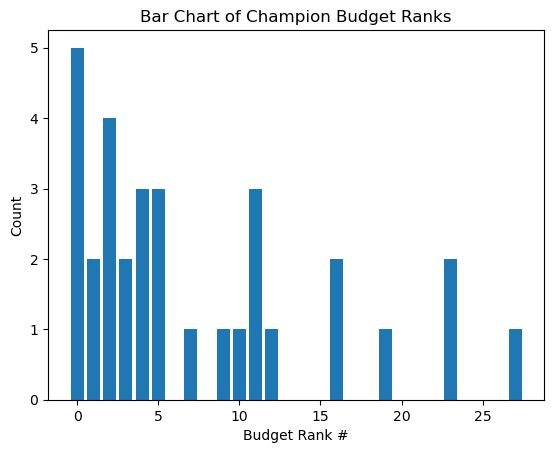

7.4375
4.5


In [12]:
count = winningteams_df['Unnamed: 0'].value_counts()

plt.bar(count.index, count.values)
plt.xlabel('Budget Rank #')
plt.ylabel('Count')
plt.title('Bar Chart of Champion Budget Ranks')

plt.show()

champion_mean_rank = winningteams_df['Unnamed: 0'].mean()
champion_median_rank = winningteams_df['Unnamed: 0'].median()
print(champion_mean_rank)
print(champion_median_rank)

Correlation between 'Budget Ranking' and 'inflationAdjPayroll': 0.3216329550164967


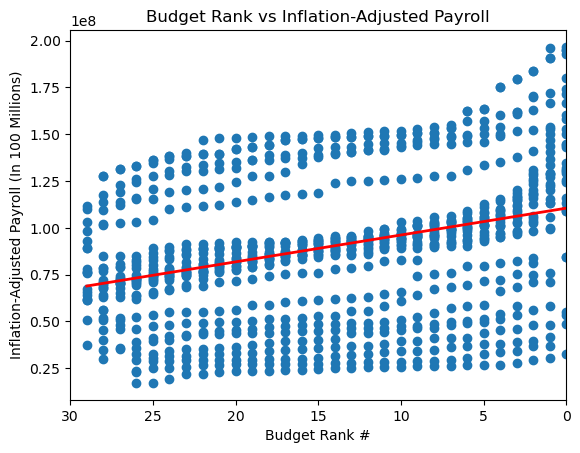

In [13]:
correlation = NBAPayroll['Unnamed: 0'].corr(NBAPayroll['inflationAdjPayroll'])

# I Have to multiply this number by -1 as ranking goes from 0 (best rank) to 30 (last rank)
print(f"Correlation between 'Budget Ranking' and 'inflationAdjPayroll': {-1 * correlation}")

from scipy.optimize import curve_fit

def line(x, m, b):
    return m * x + b

x = NBAPayroll['Unnamed: 0'].values
y = NBAPayroll['inflationAdjPayroll'].values

best_fit_parameters, blank = curve_fit(line, x, y)

A_expected = best_fit_parameters[0]  
B_expected = best_fit_parameters[1]
y_expected = line(x, A_expected, B_expected)

plt.scatter(NBAPayroll['Unnamed: 0'], NBAPayroll['inflationAdjPayroll'])
plt.plot(x, y_expected, color='red', linewidth=2)
plt.xlabel('Budget Rank #')
plt.ylabel('Inflation-Adjusted Payroll (In 100 Millions)')
plt.title('Budget Rank vs Inflation-Adjusted Payroll')
plt.xlim(30, 0)

plt.show()

In [14]:
rank4 = NBAPayroll[(NBAPayroll['Unnamed: 0'] == 4) & (NBAPayroll['seasonStartYear'] == 2021)]
rank5 = NBAPayroll[(NBAPayroll['Unnamed: 0'] == 5) & (NBAPayroll['seasonStartYear'] == 2021)]
print(rank4['inflationAdjPayroll'])
print(rank5['inflationAdjPayroll'])

avg1 = (175450332 + 163328668) / 2

rank7 = NBAPayroll[(NBAPayroll['Unnamed: 0'] == 7) & (NBAPayroll['seasonStartYear'] == 2021)]
rank8 = NBAPayroll[(NBAPayroll['Unnamed: 0'] == 8) & (NBAPayroll['seasonStartYear'] == 2021)]
print(rank7['inflationAdjPayroll'])
print(rank8['inflationAdjPayroll'])

avg2 = ((153600014 * 57) + (150700383 * 43)) / 100

champion_filter = winningteams_df[(winningteams_df['seasonStartYear'] >= 2016) & (winningteams_df['seasonStartYear'] <= 2021)]
champion_mean_recent = champion_filter['inflationAdjPayroll'].mean()

champion_2021 = winningteams_df[winningteams_df['seasonStartYear'] == 2021]
print(champion_2021['inflationAdjPayroll'])



910    175450332.0
940    175450332.0
Name: inflationAdjPayroll, dtype: float64
911    163328668.0
941    163328668.0
Name: inflationAdjPayroll, dtype: float64
913    153600014.0
943    153600014.0
Name: inflationAdjPayroll, dtype: float64
914    150700383.0
944    150700383.0
Name: inflationAdjPayroll, dtype: float64
31    175450332.0
Name: inflationAdjPayroll, dtype: float64


In [15]:
#Final Answers: 

print('$'+ str(avg1)) ## Average cost to win using MEDIAN champion ranking with 2021 inflation-adjusted budget.
print('$'+ str(avg2)) ## Average cost to win using MEAN champion ranking with 2021 inflation-adjusted budget.
print('$'+ str(champion_mean_recent)) ## Average cost to win using champion mean inflation-adjusted budget from 2016-2021.
print('$'+'175450332.0') ## 2021 Champions inflation-adjusted Team Budget

$169389500.0
$152353172.67
$162293266.83333334
$175450332.0


## Results

I have achieved a large amount of results from this project. The first series of results were my visual conclusions from my pi charts. I found that from 1990 to 2000 the Payroll for NBA teams increased by 400%+, however from 2000 to 2010 the Payroll only increased by an additional ~20%. By 2018 the Payrolls increased by an additional 50% and by 2020 an additional ~15%. This totals for an increase of over 500% in NBA team budgets in the last 30 years. This actually answers the second smaller part to my question, 'how has the cost of winning changed over time'. 

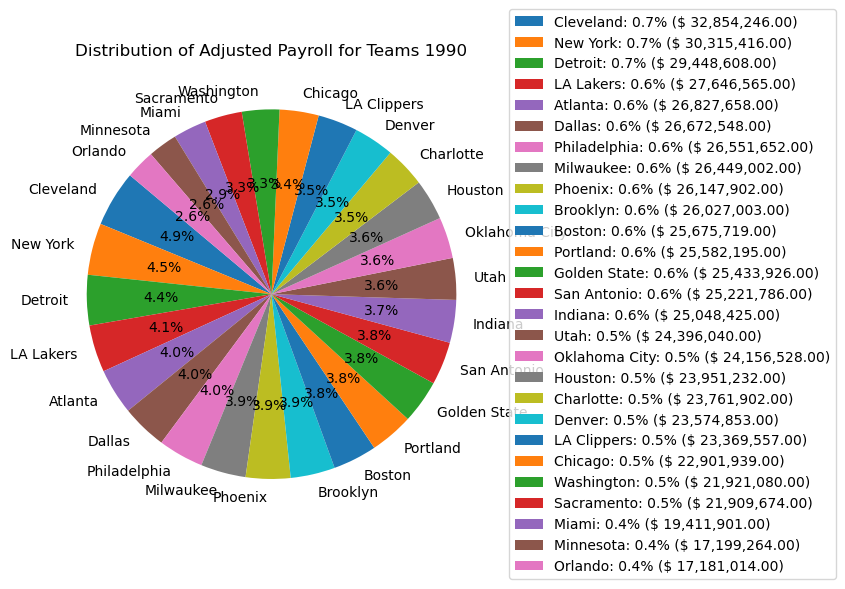

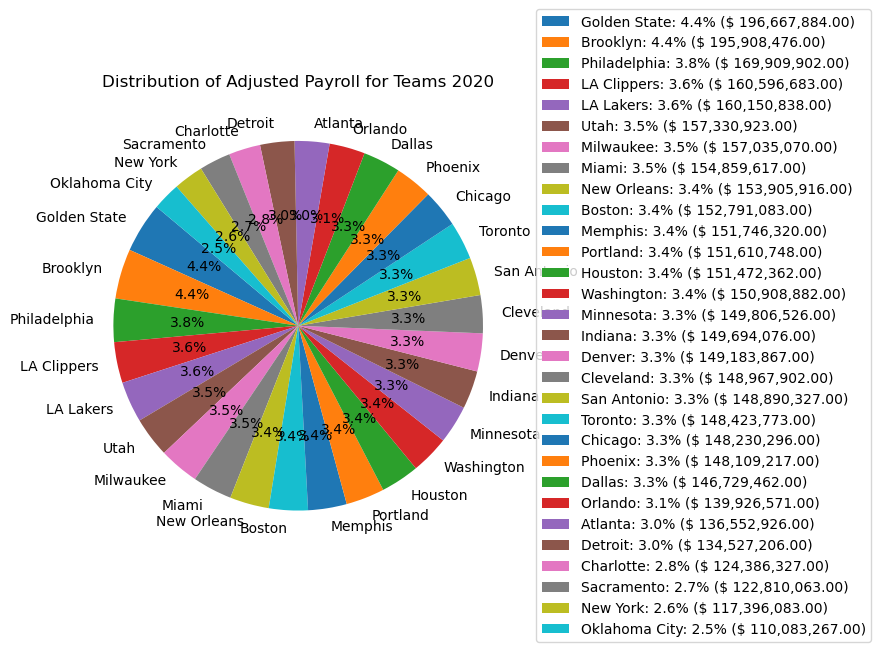

In [16]:
plt.figure(figsize=(10, 6))
plt.pie(NBA1990_payroll['inflationAdjPayroll'], labels=NBA1990_payroll['team'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Adjusted Payroll for Teams 1990')
legend_labels = [f"{team}: {percentage:.1f}% ($ {inflationAdjPayroll:,.2f})" 
                 for team, percentage, inflationAdjPayroll in zip(NBA1990_payroll['team'], 
                                                         (NBA1990_payroll['inflationAdjPayroll'] / total_payroll) * 100, 
                                                         NBA1990_payroll['inflationAdjPayroll'])]

plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

plt.figure(figsize=(10, 6))
plt.pie(NBA2020_payroll['inflationAdjPayroll'], labels=NBA2020_payroll['team'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Adjusted Payroll for Teams 2020')
legend_labels = [f"{team}: {percentage:.1f}% ($ {inflationAdjPayroll:,.2f})" 
                 for team, percentage, inflationAdjPayroll in zip(NBA2020_payroll['team'], 
                                                         (NBA2020_payroll['inflationAdjPayroll'] / total_payroll) * 100, 
                                                         NBA2020_payroll['inflationAdjPayroll'])]

plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

The next series of results I got were from taking a deeper look at the trends of teams that won multiple consecutive championships. To put my findings simply: I was able to visually observe that massive jumps in budget came with championship wins generally. And if they didnt come the season of the first win, they came shortly after. 

The next results I have are these charts below. These charts were created using my created dataframes of champion teams of each year, as well as the average payroll of teams each year. After plotting the first I made the second two, zooming in on certain interesting time periods for smaller trends.

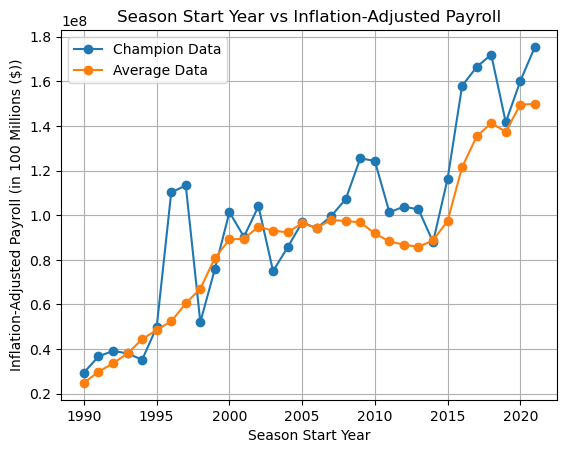

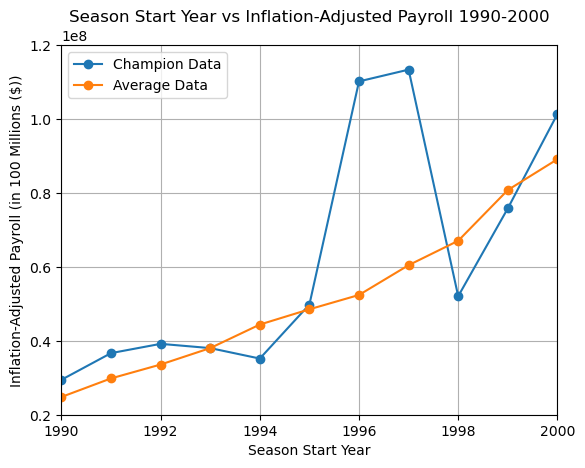

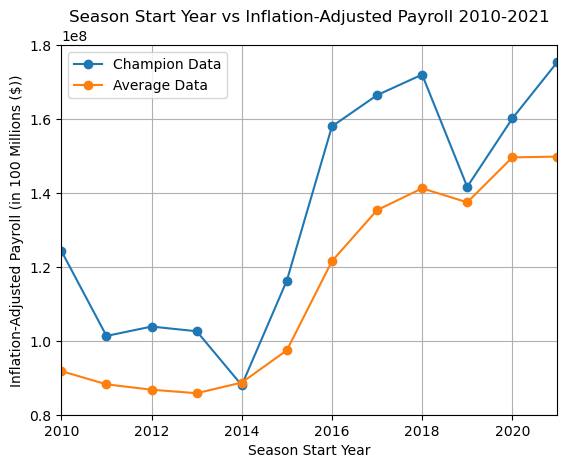

In [17]:
plt.plot(winningteams_df['seasonStartYear'], winningteams_df['inflationAdjPayroll'], 'o', linestyle='-', label='Champion Data')
plt.plot(average_payroll['seasonStartYear'], average_payroll['AverageInflationAdjPayroll'], 'o', linestyle='-', label = "Average Data")
plt.title('Season Start Year vs Inflation-Adjusted Payroll')
plt.xlabel('Season Start Year')
plt.ylabel('Inflation-Adjusted Payroll (in 100 Millions ($))')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(winningteams_df['seasonStartYear'], winningteams_df['inflationAdjPayroll'], 'o', linestyle='-', label='Champion Data')
plt.plot(average_payroll['seasonStartYear'], average_payroll['AverageInflationAdjPayroll'], 'o', linestyle='-', label = "Average Data")
plt.xlim(1990, 2000)
plt.ylim(20000000, 120000000)
plt.title('Season Start Year vs Inflation-Adjusted Payroll 1990-2000')
plt.xlabel('Season Start Year')
plt.ylabel('Inflation-Adjusted Payroll (in 100 Millions ($))')
plt.legend()
plt.grid(True)
plt.show()


plt.plot(winningteams_df['seasonStartYear'], winningteams_df['inflationAdjPayroll'], 'o', linestyle='-', label='Champion Data')
plt.plot(average_payroll['seasonStartYear'], average_payroll['AverageInflationAdjPayroll'], 'o', linestyle='-', label = "Average Data")
plt.xlim(2010, 2021)
plt.ylim(80000000, 180000000)
plt.title('Season Start Year vs Inflation-Adjusted Payroll 2010-2021')
plt.xlabel('Season Start Year')
plt.ylabel('Inflation-Adjusted Payroll (in 100 Millions ($))')
plt.legend()
plt.grid(True)
plt.show()

My last piece to my results is a plotted Bar Chart of the Champion team budget ranking for each year. This ranking is basically where they stand on how high their budget is (0 being the highest and 30 the lowest). It can clearly be seen that the majority of the teams have a budget ranking from 0 to 5. The most singlehanded championships are teams with the highest, and third highest budget ranking. I then calculated and printed the mean and median rank for champion teams. 

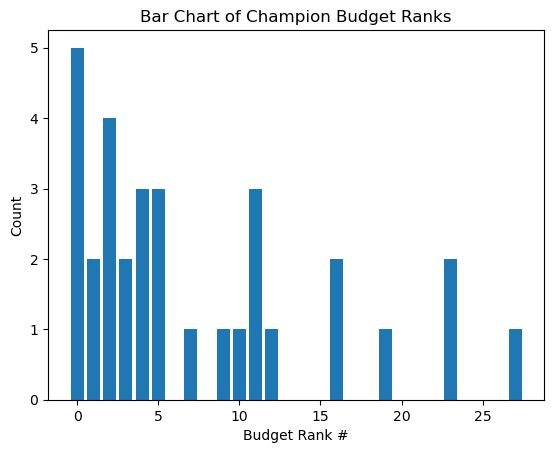

7.4375
4.5


In [18]:
plt.bar(count.index, count.values)
plt.xlabel('Budget Rank #')
plt.ylabel('Count')
plt.title('Bar Chart of Champion Budget Ranks')

plt.show()

champion_mean_rank = winningteams_df['Unnamed: 0'].mean()
champion_median_rank = winningteams_df['Unnamed: 0'].median()
print(champion_mean_rank)
print(champion_median_rank)

To finally come to some solid conclusions, I developed 4 different answers to my main question. This question is how much does it cost to win a championship in the NBA today? These answers are modernized and were calculated to be as accurate as possible in todays world. 

In [19]:
print('$'+ str(avg1)) ## Average cost to win using MEDIAN champion ranking with 2021 inflation-adjusted budget.
print('$'+ str(avg2)) ## Average cost to win using MEAN champion ranking with 2021 inflation-adjusted budget.
print('$'+ str(champion_mean_recent)) ## Average cost to win using champion mean inflation-adjusted budget from 2016-2021.
print('$'+'175450332.0') ## 2021 Champions inflation-adjusted Team Budget

$169389500.0
$152353172.67
$162293266.83333334
$175450332.0


## Discussion and Conclusion

I have a large amount of takeaways from these results. The first and most important takeway is that today becoming a champion in the NBA takes a team worth about 165 million. 150 on the low end and 175 on the high end. The next is that over the last 30 years, the price of winning a championship, or even having a team in the NBA has increased over 500%. This answers the second part to my question. I also confirmed my assumption that having a top budget gives a huge edge in winning. 

Through this project I ran into multiple obstacles. The most common being asking myself: "what next?". This is something I was constantly overcoming working through this project and finding a creative way to answer my questions. I also ran into many roadblocks trying to put an idea that I had into existance and getting errors back. To work through these problems I was able to find sources on the internet to push me forward, and continued to motivate myself with the results I was achieving

If I were to do this project over again, I would start with a more concise plan of exactly how I am going to work with the data. If I did this I would be able to avoid stressing about making a plan on the run as I did. However, I am very happy with my work and results. 

### References

'The team Payroll and player salary data was scraped from Hoops Hype.' - datasets downloaded at :

Lauton, Logan. “NBA Players &amp; Team Data.” Kaggle, 6 Apr. 2023, www.kaggle.com/datasets/loganlauton/nba-players-and-team-data/. 



For finding the champions of each year / season :

“List of NBA Champions.” Wikipedia, Wikimedia Foundation, 3 Nov. 2023, en.wikipedia.org/wiki/List_of_NBA_champions. 



For help creating pi charts :

Matplotlib Pie Charts, www.w3schools.com/python/matplotlib_pie_charts.asp. Accessed Nov. 2023. 

“Pie Charts#.” Pie Charts - Matplotlib 3.8.2 Documentation, matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html. Accessed Nov. 2023. 



For more complex use of legends : 

“Legend Guide¶.” Legend Guide - Matplotlib 1.3.1 Documentation, matplotlib.org/1.3.1/users/legend_guide.html. Accessed Nov. 2023. 



For cleaning columns of '$' and ',': 

Many. “Trying to Remove Commas and Dollars Signs with Pandas in Python.” Stack Overflow, Aug. 2016, stackoverflow.com/questions/38516481/trying-to-remove-commas-and-dollars-signs-with-pandas-in-python. 



Using value_counts() : 

Parulpandey. “Five Ways to Use Value_counts().” Kaggle, Kaggle, 25 Jan. 2020, www.kaggle.com/code/parulpandey/five-ways-to-use-value-counts. 